# One faulty gate: coherent error and syndrome analysis

We model the first encoding gate as $\widetilde{CX}_{0,1}=R_x^{(1)}(\epsilon)CX_{0,1}$. All other gates and measurements remain ideal.

## 1. Theory

For $|\psi_L\rangle=\alpha|000\rangle+\beta|111\rangle$, the residual rotation gives

$$|\widetilde{\psi}_L\rangle=\cos(\epsilon/2)|\psi_L\rangle-i\sin(\epsilon/2)X_1|\psi_L\rangle.$$

The two branches have syndromes `00` and `11`, so $P(00)=\cos^2(\epsilon/2)$ and $P(11)=\sin^2(\epsilon/2)$.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (
    build_syndrome_circuit,
    counts_to_probabilities,
    run_error_sweep,
    run_faulty_cx_syndrome,
    theoretical_syndrome_probabilities,
)

EPSILON = 0.20
SHOTS = 1024
SEED = 42

## 2. Inspect the circuit

The error is in the Aer `NoiseModel`, so the drawn circuit looks ideal. It is attached only to the ordered physical pair `[0, 1]`.

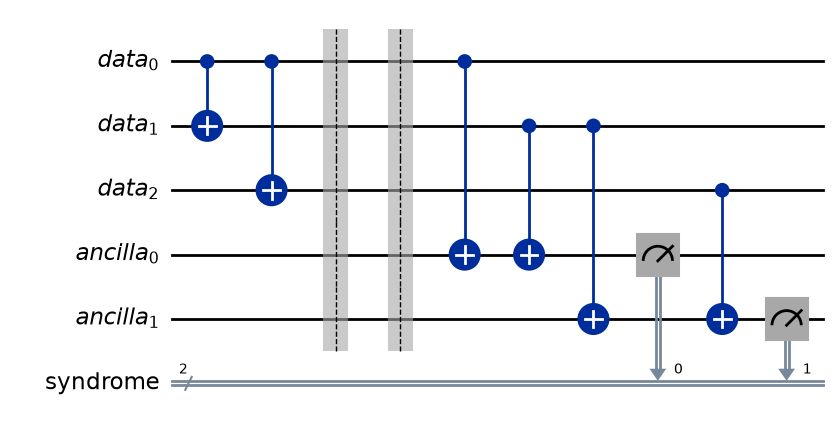

In [9]:
circuit = build_syndrome_circuit(error_qubit=None, logical_value=0)
circuit.draw(output="mpl", fold=-1)

## 3. Predict and sample the syndrome distribution

At $\epsilon=0.20$ radians, the expected `11` rate is about one percent.

In [10]:
theory = theoretical_syndrome_probabilities(EPSILON)
counts = run_faulty_cx_syndrome(EPSILON, shots=SHOTS, seed=SEED)
observed = counts_to_probabilities(counts)

comparison = pd.DataFrame({
    "Syndrome": list(theory),
    "Aer counts": [counts.get(s, 0) for s in theory],
    "Aer probability": [observed[s] for s in theory],
    "Theory": [theory[s] for s in theory],
})
comparison["Absolute difference"] = abs(comparison["Aer probability"] - comparison["Theory"])
comparison

,Syndrome,Aer counts,Aer probability,Theory,Absolute difference
0,00,1014,0.990234,0.990033,0.000201
1,10,0,0.000000,0.000000,0.000000
2,11,10,0.009766,0.009967,0.000201
3,01,0,0.000000,0.000000,0.000000


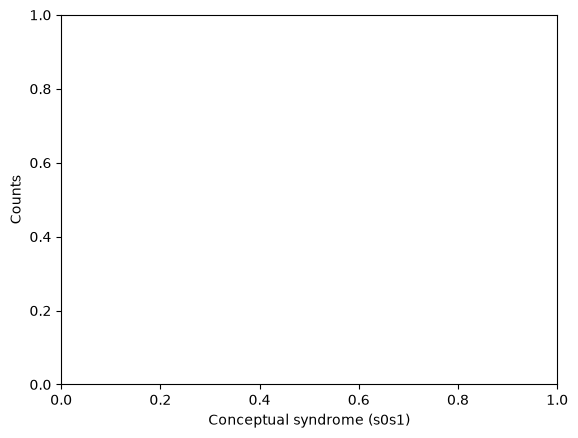

In [11]:
plot_histogram(counts, title=f"Faulty CX(0, 1): epsilon = {EPSILON:.2f} rad")
plt.xlabel("Conceptual syndrome (s0s1)")
plt.ylabel("Counts")
plt.show()

## 4. Sweep the error angle

The `11` frequency is our observable calibration signal. The next stage will vary a compensating angle to minimize it.

In [13]:
epsilon_values = np.linspace(0.0, 0.8, 17)
sweep = pd.DataFrame(run_error_sweep(epsilon_values, shots=1024, seed=SEED))
sweep

,epsilon,shots,count_00,count_11,p00_empirical,p11_empirical,p00_theory,p11_theory,absolute_error_p11
0,0.00,1024,1024,0,1.000000,0.000000,1.000000,0.000000,0.000000
1,0.05,1024,1024,0,1.000000,0.000000,0.999375,0.000625,0.000625
2,0.10,1024,1022,2,0.998047,0.001953,0.997502,0.002498,0.000545
3,0.15,1024,1016,8,0.992188,0.007812,0.994386,0.005614,0.002198
4,0.20,1024,1019,5,0.995117,0.004883,0.990033,0.009967,0.005084
5,0.25,1024,1010,14,0.986328,0.013672,0.984456,0.015544,0.001872
6,0.30,1024,1004,20,0.980469,0.019531,0.977668,0.022332,0.002801
7,0.35,1024,994,30,0.970703,0.029297,0.969686,0.030314,0.001017
8,0.40,1024,984,40,0.960938,0.039062,0.960530,0.039470,0.000407
9,0.45,1024,978,46,0.955078,0.044922,0.950224,0.049776,0.004855


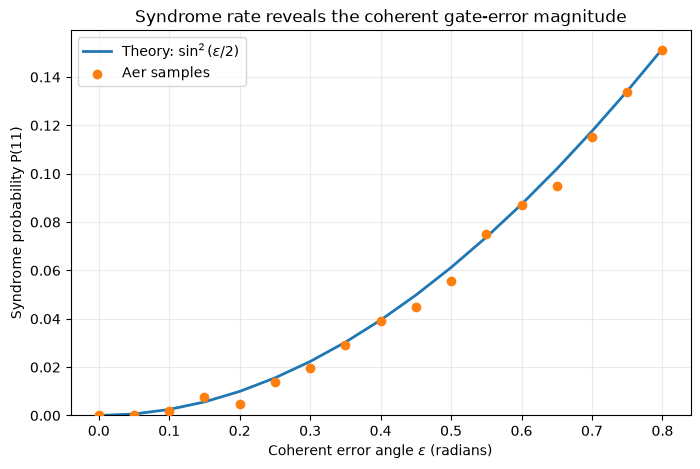

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep["epsilon"], sweep["p11_theory"], label=r"Theory: $\sin^2(\epsilon/2)$", linewidth=2)
ax.scatter(sweep["epsilon"], sweep["p11_empirical"], label="Aer samples", color="tab:orange", zorder=3)
ax.set(xlabel=r"Coherent error angle $\epsilon$ (radians)", ylabel="Syndrome probability P(11)", title="Syndrome rate reveals the coherent gate-error magnitude")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 5. Numerical checks

In [7]:
p_11 = theory["11"]
standard_error = np.sqrt(p_11 * (1 - p_11) / SHOTS)
assert set(counts) <= {"00", "11"}
assert abs(observed["11"] - p_11) <= 5 * standard_error + 1 / SHOTS
assert sweep["absolute_error_p11"].max() < 0.03
print(f"Injected angle: {EPSILON:.3f} rad")
print(f"Theory P(11):   {p_11:.6f}")
print(f"Aer P(11):      {observed['11']:.6f}")
print("Analytic-versus-Aer validation: PASS")

Injected angle: 0.200 rad
Theory P(11):   0.009967
Aer P(11):      0.009900
Analytic-versus-Aer validation: PASS


## Conclusion

Syndrome measurement converts the coherent branches into a classical distribution: `00` with probability $\cos^2(\epsilon/2)$ and `11` with probability $\sin^2(\epsilon/2)$. This measured `11` rate is our first calibration signal.